## Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Inputting Data

In [ ]:
dataset=pd.read_csv(r'Simple Linear Regression/height-weight.csv')
dataset.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


## Plotting Data

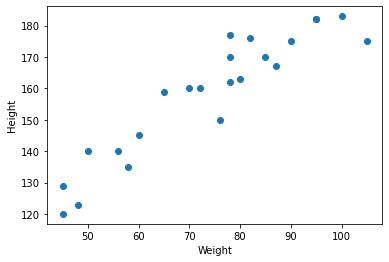

In [6]:
plt.scatter(dataset['Weight'],dataset['Height']);
plt.xlabel('Weight');
plt.ylabel('Height');

## Seperating Independent and Dependent Features

In [60]:
X=dataset[['Weight']]
y=dataset['Height']

print(X.shape) # 2D 
print(y.shape) # 1D

(23, 1)
(23,)


## Splitting Data into Training and Testing Data

In [61]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)
X_train.shape

(17, 1)

## Standardizing the Data (z-score)

In [31]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_train

array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [ ]:
X_test=scaler.transform(X_test)

## Applying the Linear Regression Model

In [33]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train,y_train)
y_pred=regression.predict(X_test)

LinearRegression()

In [34]:
print(regression.coef_)
print(regression.intercept_)

[17.2982057]
156.47058823529412


## Plotting chart between X_train and Output of X_train(By Model)

C:\Users\HP\anaconda3\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


InvalidIndexError: (slice(None, None, None), None)

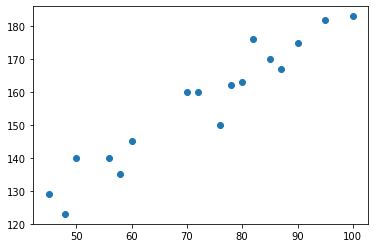

In [62]:
plt.scatter(X_train,y_train);
plt.plot(X_train,regression.predict(X_train));
plt.xlabel('Weight');
plt.ylabel('Height');

## Plotting chart between X_test and Output of X_test(By Model)

C:\Users\HP\anaconda3\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


InvalidIndexError: (slice(None, None, None), None)

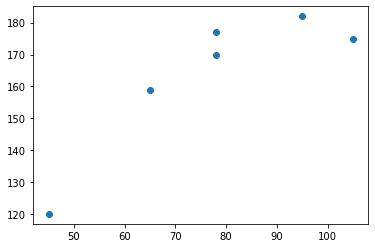

In [63]:
plt.scatter(X_test,y_test)
plt.plot(X_test,regression.predict(X_test))

## Performance Metrics

In [51]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
print(mean_absolute_error(y_pred,y_test))
print(mean_squared_error(y_pred,y_test))
print(root_mean_squared_error(y_pred,y_test))
print(r2_score(y_pred,y_test))
score=r2_score(y_pred,y_test)
print(1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)) # Adjusted R2

9.665125886795005
114.84069295228699
10.716374991212605
0.7242334405003443
0.6552918006254305


# OLS (Ordinary Least Squares) Linear Regression

In [52]:
import statsmodels.api as sm

model=sm.OLS(y_train,X_train).fit()

In [53]:
prediction=model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [54]:
model.summary()

C:\Users\HP\anaconda3\lib\site-packages\scipy\stats\stats.py:1541: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=17
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Thu, 07 May 2026   Prob (F-statistic):                       0.664
Time:                        20:22:57   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            17.2982     39.138      0.442      0.664     -65.671     100.267
==============================================================================
Omnibus:                        0.135   Durbin-Watson:                   0.002
Prob(Omnibus):                  0.935   Jarque-Bera (JB):                0.203
Skew:                          -0.166   Prob(JB):                        0.904
Kurtosis:                       2.581   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [58]:
model.predict(scaler.transform([[193]]))

C:\Users\HP\anaconda3\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([126.30578704])